# Group 2: Stock Factor Betas (Steps 1-5)

Estimate each stock's currency, AUD, market, and sector betas by regressing on one
factor at a time and carrying the residuals forward, so each beta is independent of the
factors before it. All data comes from group0's `companies_and_staggered_returns.xlsx`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm

DATA_FILE = Path("../data/companies_and_staggered_returns.xlsx")
STAGGERS = ["stagger_1", "stagger_2", "stagger_3", "stagger_4"]

## Load the data

Get the stock list from the `Companies` sheet (drop the ETF/FX rows and duplicate
tickers); the returns and sector factors are loaded per stagger inside the main loop.

In [2]:
companies = pd.read_excel(DATA_FILE, sheet_name="Companies")

# Keep only real stocks: one row per ticker, and no ETF / FX / SPY rows
stocks = (
    companies
    .dropna(subset=["sector"])
    .drop_duplicates(subset=["ticker"])
    .reset_index(drop=True)
)

print(f"{len(stocks)} stocks")
print(f"Foreign stocks: {stocks.loc[stocks['currency'] != 'USD', 'ticker'].tolist()}")
stocks

43 stocks
Foreign stocks: ['VIST', 'STX', 'NTR', 'ASND', 'NOK']


,ticker,company_name,country,sector,currency
0,VST,Vistra Corp.,United States,Utilities,USD
1,VIST,"Vista Energy, S.A.B. de C.V.",Mexico,Energy,MXN
2,AEP,"American Electric Power Company, Inc.",United States,Utilities,USD
3,ETR,Entergy Corporation,United States,Utilities,USD
4,DIS,The Walt Disney Company,United States,Communication Services,USD
5,CMG,"Chipotle Mexican Grill, Inc.",United States,Consumer Discretionary,USD
6,AMZN,"Amazon.com, Inc.",United States,Consumer Discretionary,USD
7,FIX,"Comfort Systems USA, Inc.",United States,Industrials,USD
8,STX,Seagate Technology Holdings plc,Singapore,Technology,SGD
9,VLO,Valero Energy Corporation,United States,Energy,USD


In [3]:
# Map each GICS sector to its SPDR sector ETF (the residual factor columns
# in group0's file are named like 'XLB_residual')
sector_to_etf = {
    "Communication Services": "XLC",
    "Consumer Discretionary": "XLY",
    "Consumer Staples": "XLP",
    "Energy": "XLE",
    "Financials": "XLF",
    "Health Care": "XLV",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Technology": "XLK",
    "Utilities": "XLU",
}

# The FX return columns are named like 'MXN/USD', so a stock's currency code
# tells us which column to use
def fx_column(currency):
    return currency + "/USD"


## The regression helper

Every step is the same OLS regression with an intercept; the residual carried to the
next step is `return - (alpha + beta * factor)`, same as group0.

In [4]:
def regress(y, x):
    """Regress y on x (with an intercept). Return beta, alpha, and beta's t-stat."""
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing="drop").fit()
    beta = model.params.iloc[1]
    alpha = model.params.iloc[0]
    t_stat = model.tvalues.iloc[1]
    return beta, alpha, t_stat

## Steps 1-5: the stepwise regressions

For each stock in each stagger: (1) foreign stocks regress on their local currency and
keep the beta (US stocks skip this); (2) regress the residuals on AUD and keep the beta
only if |t| > 2, otherwise set it to 0; (3) regress on SPY, keep the beta; (4) regress
on the stock's own residual sector factor, keep the beta. What's left is the
stock-specific return.

In [5]:
beta_rows = []        # one row per stock per stagger
residuals_by_stagger = {}   # stock-specific returns, one DataFrame per stagger

for stagger in STAGGERS:
    # Load this stagger's time-weighted returns and residual sector factors
    returns = pd.read_excel(
        DATA_FILE, sheet_name=stagger, skiprows=254, nrows=80, parse_dates=["date"]
    ).set_index("date")
    sector_factors = pd.read_excel(
        DATA_FILE, sheet_name=stagger, skiprows=338, nrows=80, parse_dates=["date"]
    ).set_index("date")

    stock_specific = pd.DataFrame(index=returns.index)

    for _, stock in stocks.iterrows():
        ticker = stock["ticker"]
        r = returns[ticker].astype(float)

        # Step 1: own local currency (prior, keep the beta)
        if stock["currency"] != "USD":
            fx = returns[fx_column(stock["currency"])].astype(float)
            beta_fx, alpha, _ = regress(r, fx)
            r = r - (alpha + beta_fx * fx)
        else:
            beta_fx = 0.0   # US stocks skip this step

        # Steps 2-3: AUD (not a prior, must pass |t| > 2)
        aud = returns["AUD/USD"].astype(float)
        beta_aud, alpha, t_aud = regress(r, aud)
        if abs(t_aud) > 2:
            r = r - (alpha + beta_aud * aud)
        else:
            beta_aud = 0.0  # insignificant -> beta set to zero, returns unchanged

        # Step 4: market (prior, keep the beta)
        spy = returns["SPY"].astype(float)
        beta_mkt, alpha, _ = regress(r, spy)
        r = r - (alpha + beta_mkt * spy)

        # Step 5: own residual sector factor (prior, keep the beta)
        etf = sector_to_etf[stock["sector"]]
        sector = sector_factors[etf + "_residual"].astype(float)
        beta_sector, alpha, _ = regress(r, sector)
        r = r - (alpha + beta_sector * sector)

        # r is now the stock-specific return
        stock_specific[ticker] = r
        beta_rows.append({
            "stagger": stagger,
            "ticker": ticker,
            "sector": stock["sector"],
            "currency": stock["currency"],
            "beta_fx": beta_fx,
            "beta_aud": beta_aud,
            "aud_t_stat": t_aud,
            "beta_mkt": beta_mkt,
            "beta_sector": beta_sector,
            "residual_risk": r.std(),
        })

    residuals_by_stagger[stagger] = stock_specific

betas = pd.DataFrame(beta_rows)
print(f"{len(betas)} stock-stagger beta sets estimated")
betas.head(10)

172 stock-stagger beta sets estimated


,stagger,ticker,sector,currency,beta_fx,beta_aud,aud_t_stat,beta_mkt,beta_sector,residual_risk
0,stagger_1,VST,Utilities,USD,0.000000,0.000000,0.888333,1.080770,0.773940,0.102756
1,stagger_1,VIST,Energy,MXN,0.095817,0.000000,-0.048017,-0.105156,0.901289,0.103361
2,stagger_1,AEP,Utilities,USD,0.000000,0.867205,3.186870,0.090570,0.977930,0.033716
3,stagger_1,ETR,Utilities,USD,0.000000,0.000000,1.590126,0.355563,0.942475,0.032963
4,stagger_1,DIS,Communication Services,USD,0.000000,0.947990,2.294841,1.073992,0.473726,0.065913
5,stagger_1,CMG,Consumer Discretionary,USD,0.000000,1.042484,2.030972,0.658024,0.531742,0.094809
6,stagger_1,AMZN,Consumer Discretionary,USD,0.000000,0.000000,1.858281,1.619583,1.047856,0.055626
7,stagger_1,FIX,Industrials,USD,0.000000,1.569809,2.708158,1.164377,0.693957,0.100189
8,stagger_1,STX,Technology,SGD,3.872352,0.000000,1.309511,2.096842,2.529228,0.115849
9,stagger_1,VLO,Energy,USD,0.000000,0.000000,0.631491,-0.076133,1.193654,0.068946


## Average the four staggers

Average each stock's betas across the four staggers to smooth out sample-specific
estimation error.

In [6]:
beta_columns = ["beta_fx", "beta_aud", "beta_mkt", "beta_sector", "residual_risk"]

avg_betas = betas.groupby("ticker")[beta_columns].mean()

# put sector / currency labels back on
avg_betas = stocks.set_index("ticker")[["sector", "currency"]].join(avg_betas)
avg_betas = avg_betas.sort_values("beta_mkt", ascending=False)

print("How often did the AUD beta pass |t| > 2?",
      f"{(betas['beta_aud'] != 0).sum()} of {len(betas)} stock-stagger regressions")
avg_betas.round(3)

How often did the AUD beta pass |t| > 2? 105 of 172 stock-stagger regressions


,sector,currency,beta_fx,beta_aud,beta_mkt,beta_sector,residual_risk
ticker,,,,,,,
UPST,Financials,USD,0.000,1.503,2.579,2.157,0.238
AMD,Technology,USD,0.000,1.439,2.089,3.203,0.115
NET,Technology,USD,0.000,0.798,1.718,0.554,0.146
MU,Technology,USD,0.000,2.126,1.620,2.903,0.138
STX,Technology,SGD,3.453,1.176,1.568,2.015,0.118
WDC,Technology,USD,0.000,2.313,1.418,1.808,0.135
HPE,Technology,USD,0.000,0.814,1.378,1.248,0.104
DOCN,Technology,USD,0.000,2.204,1.347,2.474,0.170
AMZN,Consumer Discretionary,USD,0.000,0.649,1.338,1.040,0.063


## Verification 1: orthogonality

The stock-specific returns should be uncorrelated with the removed factors: sector is
exactly 0, SPY is ~0, but the foreign stocks regain some local-currency correlation
because the later AUD/SPY steps subtract components that co-move with those
currencies. Worth discussing as a group.

In [7]:
checks = []
for stagger in STAGGERS:
    returns = pd.read_excel(
        DATA_FILE, sheet_name=stagger, skiprows=254, nrows=80, parse_dates=["date"]
    ).set_index("date")
    sector_factors = pd.read_excel(
        DATA_FILE, sheet_name=stagger, skiprows=338, nrows=80, parse_dates=["date"]
    ).set_index("date")
    resid = residuals_by_stagger[stagger]

    for _, stock in stocks.iterrows():
        ticker = stock["ticker"]
        r = resid[ticker]
        etf = sector_to_etf[stock["sector"]]
        row = {
            "stagger": stagger,
            "ticker": ticker,
            "corr_spy": r.corr(returns["SPY"]),
            "corr_sector": r.corr(sector_factors[etf + "_residual"]),
        }
        # only meaningful where the factor was actually removed
        if stock["currency"] != "USD":
            row["corr_fx"] = r.corr(returns[fx_column(stock["currency"])])
        checks.append(row)

checks = pd.DataFrame(checks)
print("Largest correlation (absolute value) between the stock-specific returns")
print("and each removed factor, across all stocks and staggers:")
checks[["corr_spy", "corr_sector", "corr_fx"]].abs().max().round(6)

Largest correlation (absolute value) between the stock-specific returns
and each removed factor, across all stocks and staggers:


corr_spy       0.010621
corr_sector    0.000000
corr_fx        0.350508
dtype: float64

## Verification 2: a visual example

One stock's returns vs SPY before the regressions, and its stock-specific returns after
(no market relationship left).

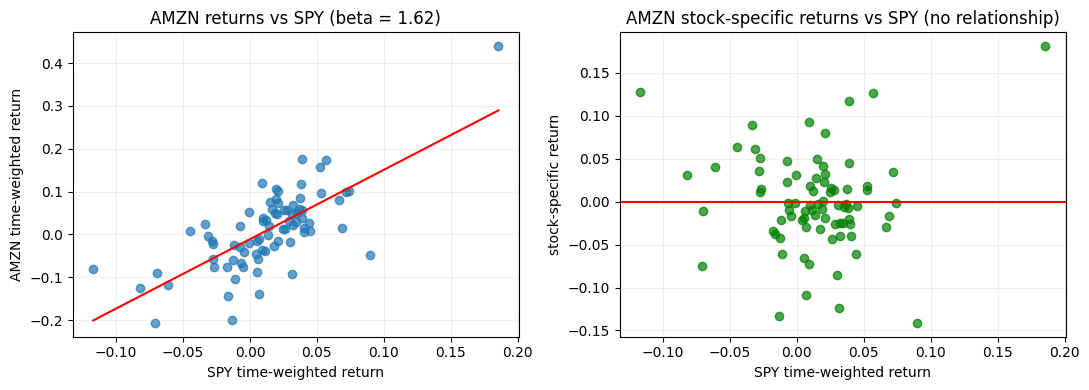

In [8]:
import matplotlib.pyplot as plt

EXAMPLE = "AMZN"
stagger = "stagger_1"

returns = pd.read_excel(
    DATA_FILE, sheet_name=stagger, skiprows=254, nrows=80, parse_dates=["date"]
).set_index("date")

raw = returns[EXAMPLE].astype(float)
spy = returns["SPY"].astype(float)
final = residuals_by_stagger[stagger][EXAMPLE]

beta_raw, alpha_raw, _ = regress(raw, spy)
line_x = np.linspace(spy.min(), spy.max(), 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(spy, raw, alpha=0.7)
axes[0].plot(line_x, alpha_raw + beta_raw * line_x, color="red")
axes[0].set_title(f"{EXAMPLE} returns vs SPY (beta = {beta_raw:.2f})")
axes[0].set_xlabel("SPY time-weighted return")
axes[0].set_ylabel(f"{EXAMPLE} time-weighted return")
axes[0].grid(alpha=0.2)

axes[1].scatter(spy, final, alpha=0.7, color="green")
axes[1].axhline(0, color="red")
axes[1].set_title(f"{EXAMPLE} stock-specific returns vs SPY (no relationship)")
axes[1].set_xlabel("SPY time-weighted return")
axes[1].set_ylabel("stock-specific return")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Save the results

Write the betas (per stagger and averaged) and the stock-specific returns to one Excel
file.

In [9]:
output_file = Path("group2_stock_betas.xlsx")

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    betas.to_excel(writer, sheet_name="Betas by Stagger", index=False)
    avg_betas.reset_index().to_excel(writer, sheet_name="Betas XRD Average", index=False)
    for stagger in STAGGERS:
        (residuals_by_stagger[stagger]
         .rename_axis("date")
         .reset_index()
         .to_excel(writer, sheet_name=f"Residuals {stagger}", index=False))

print(f"saved {output_file.resolve().name}")

saved group2_stock_betas.xlsx
